In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.model_selection import train_test_split
import math
import numpy as np

## Read in Dataset

In [67]:
df = pd.read_csv("final_merged_output.csv", low_memory = False)
df.head()

,StudyInfo_Accession,StudyInfo_MRN,StudyInfo_SeriesInfo,session.label,info_StudyDate,info_PatientBirthDate,session.age,session.age_years,session.age_weeks,session.age_months,...,167,169,170,173,176,186,188,189,Pseudonymized_MRN,_merge
0,011020-164,011020-164,011020-1643,011020-1643,NaN,NaN,NaN,NaN,NaN,NaN,...,0,0,0,0,0,0,0,0,8713edd9c0,both
1,090721-225,090721-225,090721-2255,090721-2255,NaN,NaN,NaN,NaN,NaN,NaN,...,0,0,0,0,0,0,0,0,8f832256ab,both
2,090808-015,090808-015,090808-0156,090808-0156,NaN,NaN,NaN,NaN,NaN,NaN,...,0,0,0,0,0,0,0,0,c3a2a07e0a,both
3,050912-039,050912-039,050912-0395,050912-0395,NaN,NaN,NaN,NaN,NaN,NaN,...,0,0,0,0,0,0,0,0,aa5b296324,both
4,090814-050,090814-050,090814-0505,090814-0505,NaN,NaN,NaN,NaN,NaN,NaN,...,0,0,0,0,0,0,0,0,c27653412d,both


In [68]:
sum(df["CTBiomarkers.folder"] == df["filename"])

24706

In [69]:
sum(df["session.label"] == df["filename"])

24706

In [70]:
len(df["Pseudonymized_MRN"].unique())

19620

## Filter for only those in Images

In [71]:
image_dir = "../CT-Disease-Detection/data/data"
    
# Ensure 'id' column exists
if 'filename' not in df.columns:
    raise ValueError("CSV must contain an 'id' column")

# Get set of image filenames without extension
image_ids = {os.path.splitext(f)[0] for f in os.listdir(image_dir) if f.endswith('.png')}

# Filter DataFrame
filtered_df = df[df['filename'].astype(str).isin(image_ids)]
    
print(len(filtered_df))


13437


## Renaming Columns

In [72]:
# ['GENDER', 'HCC18', 'HCC22', 'HCC85', 'HCC96', 'HCC108', 'HCC111', 'CalciumScoring_AbdominalAgatston', 'AGE']

# Rename columns
filtered_df.rename(columns={'SEX': 'GENDER',
                            '18': 'HCC18',  
                            '22': 'HCC22', 
                            '85': 'HCC85', 
                            '96': 'HCC96',
                            '108': 'HCC108',
                            '111': 'HCC111',
                            'AGE_AT_STUDY': 'AGE',
                            'filename': 'FILE',
                            '189': 'RAF'}, inplace=True)

/tmp/user/21614/ipykernel_888968/2813559295.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_df.rename(columns={'SEX': 'GENDER',


In [73]:
# Keep only a specific set of columns
columns_to_keep = ['FILE', 'GENDER', 'HCC18', 'HCC22', 'HCC85', 'HCC96', 'HCC108', 'HCC111', 'AGE', 'CalciumScoring_AbdominalAgatston', 'Pseudonymized_MRN', 'RAF']  # Replace with your desired column names
filtered_df = filtered_df[columns_to_keep]

In [74]:
filtered_df.to_csv("data/filtered_pre_proc.csv")

## Processing Column Values

In [75]:
# Convert 'GENDER' column to lowercase
if 'GENDER' in filtered_df.columns:
    filtered_df['GENDER'] = filtered_df['GENDER'].str.lower()

# Convert HCC columns: 0 -> 'ABSENT', else -> 'PRESENT'
hcc_columns = ['HCC18', 'HCC22', 'HCC85', 'HCC96', 'HCC108', 'HCC111']
for col in hcc_columns:
    if col in filtered_df.columns:
        filtered_df[col] = filtered_df[col].apply(lambda x: 'ABSENT' if x == 0 else 'PRESENT')

In [76]:
filtered_df = filtered_df[filtered_df['GENDER'] != 'unknown']
filtered_df["GENDER"].value_counts()

GENDER
female    7610
male      5823
Name: count, dtype: int64

In [77]:
filtered_df["HCC111"].unique()

array(['ABSENT', 'PRESENT'], dtype=object)

In [78]:
# Update 'CalciumScoring_AbdominalAgatston' based on value ranges
if 'CalciumScoring_AbdominalAgatston' in df.columns:
    def categorize_calcium(val):
        if val == 0:
            return 'ABSENT'
        elif 1 <= val <= 1000:
            return 'LOW'
        elif 1001 <= val <= 3000:
            return 'MEDIUM'
        elif val > 3000:
            return 'HIGH'
        return val  # fallback
    filtered_df['CalciumScoring_AbdominalAgatston'] = filtered_df['CalciumScoring_AbdominalAgatston'].apply(categorize_calcium)


In [79]:
filtered_df['CalciumScoring_AbdominalAgatston'].unique()

array(['ABSENT', 'LOW', 'HIGH', 'MEDIUM'], dtype=object)

In [80]:
filtered_df['CalciumScoring_AbdominalAgatston'].value_counts()

CalciumScoring_AbdominalAgatston
ABSENT    5905
LOW       4300
HIGH      1812
MEDIUM    1416
Name: count, dtype: int64

In [83]:
filtered_df.to_csv("data/full.csv", index=False)

## Train Test Split

In [84]:
unique_mrns = filtered_df['Pseudonymized_MRN'].unique()
train_mrns, test_mrns = train_test_split(unique_mrns, test_size=0.1, random_state=42)
train_df = filtered_df[filtered_df['Pseudonymized_MRN'].isin(train_mrns)]
test_df = filtered_df[filtered_df['Pseudonymized_MRN'].isin(test_mrns)]

# Save train and test CSVs
train_df.to_csv('data/train1.csv', index=False)
test_df.to_csv('data/test1.csv', index=False)

print(f"Train CSV saved to 'data/train1.csv'")
print(f"Test CSV saved to 'data/test1.csv'")

Train CSV saved to 'data/train1.csv'
Test CSV saved to 'data/test1.csv'


## Train and Test Counts

In [2]:
train_df = pd.read_csv("data/train1.csv")
test_df = pd.read_csv("data/test1.csv")

# Check the row counts and unique MRNs
print(f"Train DataFrame shape: {train_df.shape}")
print(f"Test DataFrame shape: {test_df.shape}")
print(f"Unique MRNs in Train: {len(train_df['Pseudonymized_MRN'].unique())}")
print(f"Unique MRNs in Test: {len(test_df['Pseudonymized_MRN'].unique())}")

Train DataFrame shape: (12060, 12)
Test DataFrame shape: (1373, 12)
Unique MRNs in Train: 9717
Unique MRNs in Test: 1080


## External Validation Set

In [2]:
df = pd.read_csv("external_validation_data/all_cases_results.csv")

In [3]:
len(df)

124

In [4]:
df.columns

Index(['folder', 'Toolkit Version', 'Levels.T10Level', 'Levels.T11Level',
       'Levels.T12Level', 'Levels.L1Level', 'Levels.L2Level', 'Levels.L3Level',
       'Levels.L4Level', 'Levels.L5Level',
       ...
       'T12FatValues.T12SATMedian', 'case_name',
       'CalculiValues.CalculiMedianHU', 'CalculiValues.CalculiVolume',
       'MuscleValues.L1MuscleMeanHU', 'MuscleValues.L1MuscleHUStd',
       'MuscleValues.L1MuscleArea', 'MuscleValues.L3MuscleMeanHU',
       'MuscleValues.L3MuscleHUStd', 'MuscleValues.L3MuscleArea'],
      dtype='object', length=112)

In [13]:
def plot_column_frequencies(df, substring):
    # Filter columns that contain the substring
    matching_cols = [col for col in df.columns if substring in col]

    if not matching_cols:
        print(f"No columns found containing '{substring}'")
        return

    n = len(matching_cols)
    cols = 2  # number of plots per row
    rows = math.ceil(n / cols)

    fig, axes = plt.subplots(rows, cols, figsize=(cols * 6, rows * 4))
    axes = axes.flatten() if n > 1 else [axes]

    for i, col in enumerate(matching_cols):
        ax = axes[i]
        value_counts = df[col].value_counts().sort_index()
        value_counts.plot(kind='line', marker='o', ax=ax)
        ax.set_title(f'Frequency Curve: {col}')
        ax.set_xlabel('Value')
        ax.set_ylabel('Count')
        ax.tick_params(axis='x', rotation=45)

    # Hide any unused subplots
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

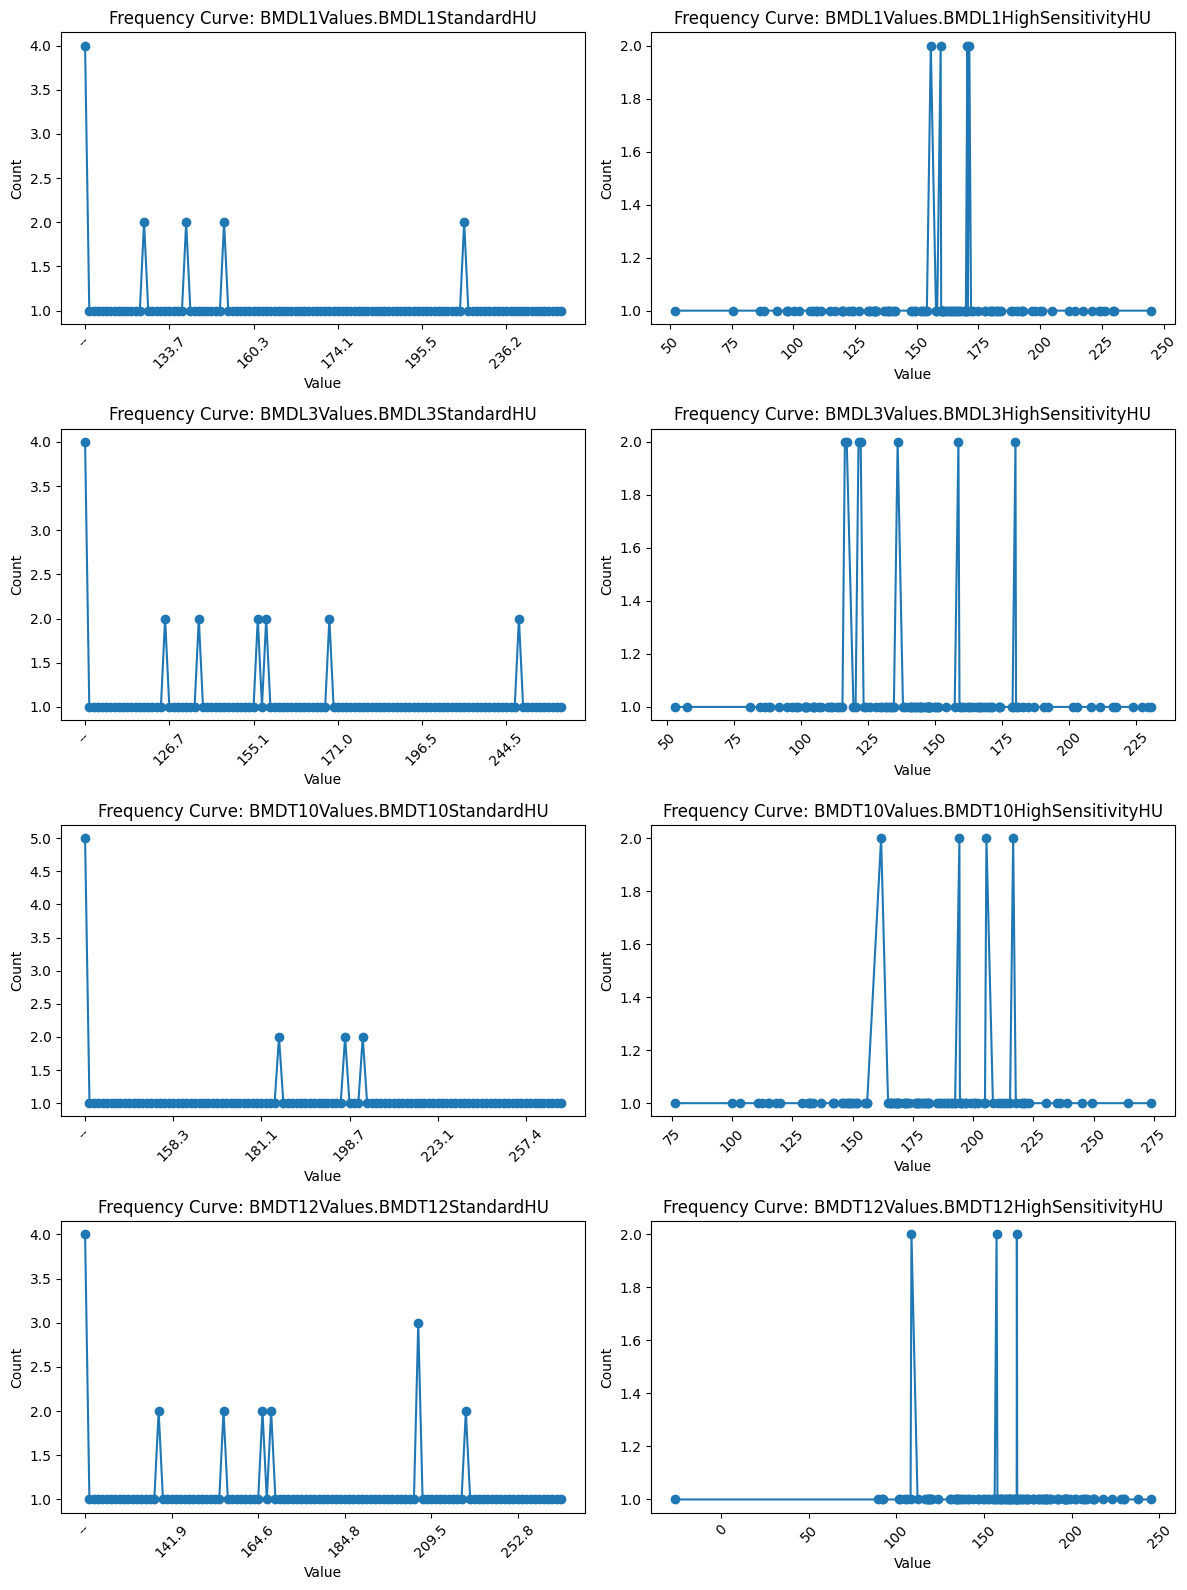

In [14]:
plot_column_frequencies(df, substring='BMD')

In [23]:
def plot_column_histograms(df, substring):
    # Find matching columns
    matching_cols = [col for col in df.columns if substring in col]

    if not matching_cols:
        print(f"No columns found containing '{substring}'")
        return

    bins = np.arange(50, 275, 5)  # Bin edges: 50 to 250

    n = len(matching_cols)
    cols = 2
    rows = math.ceil(n / cols)

    fig, axes = plt.subplots(rows, cols, figsize=(cols * 6, rows * 4))

    # Handle different shapes of axes
    if isinstance(axes, np.ndarray):
        axes = axes.flatten()
    else:
        axes = [axes]

    for i, col in enumerate(matching_cols):
        ax = axes[i]
        # Ensure numeric, drop NaNs
        data = pd.to_numeric(df[col], errors='coerce').dropna()
        ax.hist(data, bins=bins, edgecolor='black')
        ax.set_title(f'Histogram: {col}')
        ax.set_xlabel('Value')
        ax.set_ylabel('Frequency')
        ax.set_xlim(50, 250)

    # Hide unused axes
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

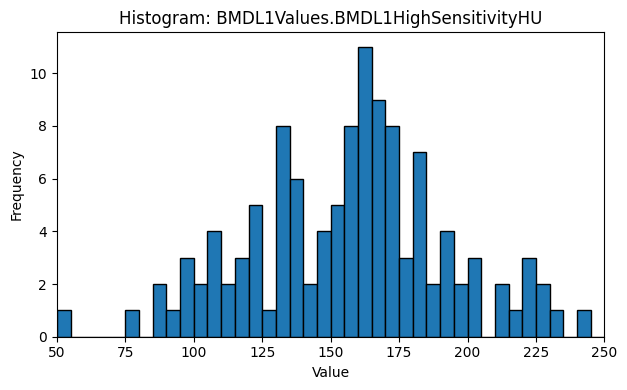

In [24]:
plot_column_histograms(df, substring='BMDL1Values.BMDL1HighSensitivity')

In [25]:
# Keep only a specific set of columns
columns_to_keep = ['folder', 'CalciumScoring.AbdominalAgatston']  # Replace with your desired column names
filtered_df = df[columns_to_keep].copy()

In [26]:
filtered_df.rename(columns={'folder': 'FILE',
                            'CalciumScoring.AbdominalAgatston': 'CalciumScoring_AbdominalAgatston'}, inplace=True)

In [27]:
filtered_df = filtered_df[filtered_df['CalciumScoring_AbdominalAgatston'] != 'Missing']

In [28]:
filtered_df['CalciumScoring_AbdominalAgatston'] = filtered_df['CalciumScoring_AbdominalAgatston'].astype(int)

In [29]:
filtered_df.dtypes

FILE                                object
CalciumScoring_AbdominalAgatston     int64
dtype: object

In [30]:
len(filtered_df)

121

In [21]:
if 'CalciumScoring_AbdominalAgatston' in filtered_df.columns:
    def categorize_calcium(val):
        if val == 0:
            return 'ABSENT'
        elif 1 <= val <= 1000:
            return 'LOW'
        elif 1001 <= val <= 3000:
            return 'MEDIUM'
        elif val > 3000:
            return 'HIGH'
        return val  # fallback
    filtered_df['CalciumScoring_AbdominalAgatston'] = filtered_df['CalciumScoring_AbdominalAgatston'].apply(categorize_calcium)
filtered_df['CalciumScoring_AbdominalAgatston'].unique()

array(['ABSENT', 'LOW', 'HIGH', 'MEDIUM'], dtype=object)

In [33]:
len(filtered_df)

121

In [32]:
sum(filtered_df["CalciumScoring_AbdominalAgatston"] >= 1000)

14

In [23]:
filtered_df["CalciumScoring_AbdominalAgatston"].value_counts()

CalciumScoring_AbdominalAgatston
ABSENT    67
LOW       40
MEDIUM    11
HIGH       3
Name: count, dtype: int64

In [22]:
filtered_df.to_csv("external_validation_data/test1.csv", index=False)